# Project Blueprint: NLP Movie Search and Recommendation System

## Mission Objective

Build a lightweight movie search engine that matches a user's natural language query against a movie dataset, ranks the most relevant movies, and returns the top matches using **TF-IDF vectors** and **cosine similarity**.

---

## Example Scenario

- **Dataset:** A messy real movie dataset with columns such as `title`, `description`, `genre`, `actors`, `review`, `directors`, `release_date`, and `vote_average`.
- **User Query:** `"space adventure with robots"`
- **Expected Output:** The system compares the cleaned query with every cleaned movie profile and returns the top matching movies.

---

## Implementation Pipeline

### Phase 1: Load and Inspect the Dataset

The dataset is loaded into a pandas DataFrame named `df`.

Important columns used later in the notebook include:

1. `title`
2. `description`
3. `genre`
4. `actors`
5. `review`
6. `directors`
7. `release_date`
8. `vote_average`

### Phase 2: Create a Working Copy and Audit Missing Values

A working copy named `df_copy` is created so that the original DataFrame `df` remains unchanged.

Missing values are checked for the selected focus columns before building the NLP pipeline.

### Phase 3: Create `combined_text`

The notebook combines multiple text columns into one searchable text column named `combined_text`.

The columns used in `combined_text` are:

- `title`
- `description`
- `genre`
- `actors`
- `review`
- `directors`

### Phase 4: Preprocess Text

The notebook defines a preprocessing function named `preprocessText()`.

This function performs:

| Step | Operation | Purpose |
| :---: | :--- | :--- |
| 1 | Convert to string | Prevents crashes from non-string input. |
| 2 | Lowercase conversion | Makes words such as `Robot`, `ROBOT`, and `robot` match. |
| 3 | Regex cleaning | Removes characters that are not lowercase letters or spaces. |
| 4 | Whitespace normalization | Converts repeated spaces into one clean space. |
| 5 | spaCy tokenization | Breaks text into tokens. |
| 6 | Stopword and punctuation filtering | Removes low-value words and punctuation. |
| 7 | Lemmatization | Reduces words to their base form. |

### Phase 5: Create TF-IDF Matrix

The cleaned movie text stored in `df_copy["cleaned_text"]` is converted into a numerical TF-IDF matrix named `tfidfMatrix`.

### Phase 6: Process the User Query

The user query is stored in `movieName`, cleaned into `cleanMovieName`, and transformed into a TF-IDF query vector named `cleanMovieNameVec`.

### Phase 7: Calculate Similarity and Return Results

The notebook calculates cosine similarity between `cleanMovieNameVec` and `tfidfMatrix`.

The top matching row positions are stored in `top3Indexes`, and the final result table is stored in `top3Movies`.

---

## Final Output

The notebook displays the top 3 recommended movies with:

- `title`
- `description`
- `genre`
- `actors`
- `directors`
- `release_date`
- `vote_average`
- `similarity_score`


## Notebook Workflow

Load dataset into `df`

↓

Inspect the dataset and missing values

↓

Create working copy `df_copy`

↓

Fill missing values in text-based columns

↓

Create `combined_text`

↓

Preprocess `combined_text` into `cleaned_text`

↓

Create TF-IDF matrix `tfidfMatrix`

↓

Accept user query as `movieName`

↓

Preprocess query into `cleanMovieName`

↓

Convert query into TF-IDF vector `cleanMovieNameVec`

↓

Calculate cosine similarity and store it in `score`

↓

Return the top 3 movies using `top3Indexes` and `top3Movies`


## Phase 1: Load the Dataset and Understand Its Structure


In [1]:
from pathlib import Path
import pandas as pd
path=Path("../data/raw/messy_real_movies_nlp_550-1.csv")
df=pd.read_csv(path)
print(f"{df.shape}\n")
print(df.head(2))
df.columns.tolist()

(550, 12)

   movie_id             title  \
0     10061  Escape from L.A.   
1    239571    The Best of Me   

                                         description           genre  \
0  This time, a cataclysmic temblor hits Los Ange...             NaN   
1  A pair of former high school sweethearts reuni...  Drama, Romance   

                                              review  \
0   not bad not great; audience_score:5.6; votes:373   
1  Mixed-to-positive audience reaction. Some view...   

                                              actors        directors  \
0  Kurt Russell | Stacy Keach | Steve Buscemi | P...   John Carpenter   
1  Michelle Monaghan, James Marsden, Liana Libera...  Michael Hoffman   

  release_date original_language vote_average  vote_count  \
0   09-08-1996                en          5.6         373   
1   16-10-2014                en          7.2         765   

            source_dataset  
0  TMDB 5000 Movie Dataset  
1  TMDB 5000 Movie Dataset  


['movie_id',
 'title',
 'description',
 'genre',
 'review',
 'actors',
 'directors',
 'release_date',
 'original_language',
 'vote_average',
 'vote_count',
 'source_dataset']

In [2]:
df.isnull().sum()

movie_id              0
title                 0
description          15
genre                13
review               14
actors                8
directors            14
release_date          8
original_language     0
vote_average          0
vote_count            0
source_dataset        0
dtype: int64

# Missing Value Audit

The first audit checks which important columns contain missing values before text processing and vectorization.

| Column Name | Missing Count | Severity Level | Risk / Impact on NLP Pipeline |
| :--- | :---: | :--- | :--- |
| `description` | 15 | Critical | Missing descriptions reduce the main plot information used for search. `TfidfVectorizer` cannot safely process `NaN` values directly. |
| `review` | 14 | High | Missing reviews remove additional opinion/context text from the movie profile. |
| `directors` | 14 | High | Missing director information reduces metadata available for search. |
| `genre` | 13 | High | Missing genres reduce category/theme information. |
| `actors` | 8 | Medium | Missing actors reduce cast-related search information. |
| `release_date` | 8 | Medium | Missing dates do not affect TF-IDF directly, but they affect final display or date-based analysis. |

The notebook handles missing values in the text-based columns before building `combined_text`.


## Phase 2: Create the Working DataFrame

The notebook creates a copy of the original DataFrame:

- Original DataFrame: `df`
- Working DataFrame: `df_copy`

The main focus columns are:

- `title`
- `description`
- `genre`
- `actors`
- `vote_average`
- `review`
- `directors`
- `release_date`

The code keeps all columns in `df_copy`, but these focus columns are inspected because they are used either for text search or final result display.


In [3]:
# Make a copy first:-
df_copy=df.copy()
# Defining the columns to focus on:-
focus_columns = [
    "title",
    "description",
    "genre",
    "actors",
    "vote_average",
    "review",
    "directors",
    "release_date"
]
# Checking missing values in the focus columns:-
na_counts = df_copy[focus_columns].isna().sum()
datatypes = df_copy[focus_columns].dtypes
na_counts=df_copy[focus_columns].isna().sum()
print("Missing Values Count in Focus Columns:")
tab= pd.DataFrame({
    "Column": focus_columns,
    "Missing Values": na_counts,
    "Data Type": datatypes,
    "NA Count": na_counts
}).reset_index(drop=True)
print(tab)



Missing Values Count in Focus Columns:
         Column  Missing Values Data Type  NA Count
0         title               0       str         0
1   description              15       str        15
2         genre              13       str        13
3        actors               8       str         8
4  vote_average               0       str         0
5        review              14       str        14
6     directors              14       str        14
7  release_date               8       str         8


## Phase 3: Create the Combined Search Text Column

In this phase, selected text columns are combined into one column called `combined_text`.

The TF-IDF system needs one searchable text document per movie.

The notebook combines:

- `title`
- `description`
- `genre`
- `actors`
- `review`
- `directors`

`vote_average` is not included in `combined_text` because it is numeric.

`release_date` is not included in `combined_text` because it is date information.

Both `vote_average` and `release_date` are still displayed later in the final result table.


In [4]:
categorical_columns = [
    "description",
    "genre",
    "actors",
    "review",
    "directors"
]
# Replacing missing values in categorical columns with "" or emptyness:-
df_copy[categorical_columns]=df_copy[categorical_columns].fillna("")

The notebook does **not** delete rows at this stage.

It only replaces missing values in selected text-based columns with empty strings so that text concatenation and TF-IDF processing can continue safely.


In [5]:
df_copy["combined_text"]=(df_copy["title"]+" "+df_copy["description"]+" "+df_copy["genre"]+" "+df_copy["actors"]+" "+df_copy["review"]+" "+df_copy["directors"])

## Pandas Text Concatenation Pipeline

The following code creates the combined movie search profile:

| Code Component | Meaning / Role | Behind-the-Scenes Action |
| :--- | :--- | :--- |
| `df_copy["combined_text"]` | Creates a new column | Stores the final searchable text for each movie. |
| `df_copy["title"]` | Adds movie title text | Allows a search query to match directly with title words. |
| `df_copy["description"]` | Adds plot/description text | Provides the main semantic meaning of the movie. |
| `df_copy["genre"]` | Adds genre text | Adds category and theme information. |
| `df_copy["actors"]` | Adds actor names | Allows actor-based matching. |
| `df_copy["review"]` | Adds review text | Adds extra descriptive or opinion-based context. |
| `df_copy["directors"]` | Adds director names | Allows director-based matching. |
| `+ " "` | Adds spaces between columns | Prevents words from different columns from being joined together incorrectly. |

The output is one large searchable string per movie, stored in `combined_text`.


In [6]:
df_copy[["title","combined_text"]].head(2)

,title,combined_text
0,Escape from L.A.,"Escape from L.A. This time, a cataclysmic temb..."
1,The Best of Me,The Best of Me A pair of former high school sw...


## Feature Engineering: Building the Movie Search Profile

| Target Column | Source Data Components | NLP Role and Purpose |
| :--- | :--- | :--- |
| `title` | Movie title | Used both as part of `combined_text` and as the readable movie name shown in the final output. |
| `combined_text` | `title` + `description` + `genre` + `actors` + `review` + `directors` | The master searchable text profile for each movie. This is the text that later gets cleaned and converted into TF-IDF vectors. |


## Phase 4: Define the Text Preprocessing Function

In this phase, the notebook prepares the text cleaning function before applying TF-IDF.

The preprocessing function will:

- convert text to lowercase
- remove unwanted characters using the `re` library
- normalize whitespace
- remove stopwords using spaCy
- lemmatize words using spaCy

The same preprocessing function, `preprocessText()`, is used for both:

- movie text from `combined_text`
- user search query from `movieName`


In [7]:
import re
import spacy

## Text Preprocessing Function Breakdown

The function `preprocessText()` takes raw movie/search text and converts it into a cleaner version for TF-IDF.

| Step | Code Snippet | What It Does | Purpose |
| :---: | :--- | :--- | :--- |
| 1 | `nlp = spacy.load("en_core_web_sm")` | Loads the English spaCy model. | Enables tokenization, stopword detection, and lemmatization. |
| 2 | `def preprocessText(text):` | Defines the preprocessing function. | Makes the cleaning process reusable. |
| 3 | `text = str(text)` | Converts input into a string. | Prevents errors if the input is not already text. |
| 4 | `text = text.lower()` | Converts text to lowercase. | Makes matching case-insensitive. |
| 5 | `re.sub(r"[^a-z\s]", " ", text)` | Replaces non-letter characters with spaces. | Removes numbers, punctuation, and symbols. |
| 6 | `re.sub(r"\s+", " ", text).strip()` | Normalizes spaces. | Replaces multiple spaces with one and removes leading/trailing spaces. |
| 7 | `doc = nlp(text)` | Processes text with spaCy. | Converts the string into spaCy tokens. |
| 8 | `clean_words = []` | Creates an empty list. | Stores the final cleaned tokens. |
| 9 | `for i in doc:` | Loops through each token. | Checks every token one by one. |
| 10 | `if not i.is_stop and not i.is_punct:` | Filters stopwords and punctuation. | Keeps only useful tokens. |
| 11 | `clean_words.append(i.lemma_)` | Adds the token lemma to the list. | Stores the base form of each useful word. |
| 12 | `clean_text = " ".join(clean_words)` | Joins cleaned words into one string. | Creates the final cleaned text. |
| 13 | `return clean_text` | Returns the cleaned string. | Sends the cleaned result back to the notebook. |


In [8]:
nlp=spacy.load("en_core_web_sm")
def preprocessText(text):
    text=str(text)
    text=text.lower()
    text=re.sub(r"[^a-z\s]", " ", text)
 # Syntax:- re.sub(pattern, replacement, string)
# [] defines character group.
# ^ inside [] means negation or not.
# a-z means all lowercase letters, 
# \s means whitespace characters.
# Find anything that is NOT a lowercase letter and NOT a space.
# Replace those characters with a space " ".
# In the following step, we will replace multiple 
# spaces with a single space and also remove leading and trailing spaces:-
    text=re.sub(r"\s+", " ", text).strip()
    doc=nlp(text) # Process the text with spaCy to create a Doc object. 
    clean_words=[]
    # Iterate through each token in the Doc object:-
    for i in doc:
        if not i.is_stop and not i.is_punct:  # Agar token stop word nahi 
            #hai aur punctuation mark nahi hai, tabhi usko aage condition k liye bhejenge:-

            #is_stop :- ka kaam hai ki wo 
            # check karta hai ki token ek stop 
            # word hai ya nahi, jaise "the", "is", 
            # "in", etc., aur unko clean words list se exclude karta hai.

            # is_punct :- ka kaam hai ki wo check karta hai ki token 
            # ek punctuation mark hai ya nahi, jaise ".", ",", "!", 
            # etc., aur unko bhi clean words list se exclude karta hai.

            # Toh yahaan humne if condition k andar check kiya hai ki agar 
            # token stop word nahi hai aur punctuation mark nahi hai, 
            # tabhi usko clean words list me add karenge:-

            clean_words.append(i.lemma_) #i.lemma_ ka kaam hai ki wo token ka lemmatized 
            #form return karta hai.
            #For example, "running" would be lemmatized to "run", and "better" 
            # would be lemmatized to "good".

    clean_text=" ".join(clean_words) #Yahaan maine clean_words list me jo 
    #bhi words add kiye hain, unko space se join karke ek single string 
    # me convert kar diya hai, jise clean_text variable me store kiya hai.
    
    return clean_text

## Text Preprocessing Pipeline Summary

The function `preprocessText()` follows this sequence:

Raw text

↓

Convert to string

↓

Lowercase

↓

Regex cleaning

↓

Whitespace normalization

↓

spaCy processing

↓

Token loop

↓

Remove stopwords and punctuation

↓

Lemmatize

↓

Join cleaned tokens

↓

Return cleaned text


In [9]:
print("Original:-")
print(df_copy.loc[134,"combined_text"])
print()
print("Preprocessed:-")
print(preprocessText(df_copy.loc[134,"combined_text"]))

Original:-
The Karate Kid Hassled by the school bullies, Daniel LaRusso has his share of adolescent woes. Luckily, his apartment building houses a resident martial arts master: Kesuke Miyagi, who agrees to train Daniel ... and ends up teaching him much more than self-defense. Armed with newfound confidence, skill and wisdom, Daniel ultimately faces off against his tormentors in this hugely popular classic underdog tale. Drama Ralph Macchio, Pat Morita, William Zabka, Martin Kove, Chad McQueen review: okay/good film, some issues; rating=6.9 John G. Avildsen

Preprocessed:-
karate kid hassle school bully daniel larusso share adolescent woe luckily apartment building house resident martial art master kesuke miyagi agree train daniel end teach self defense arm newfound confidence skill wisdom daniel ultimately face tormentor hugely popular classic underdog tale drama ralph macchio pat morita william zabka martin kove chad mcqueen review okay good film issue rat john g avildsen


## Phase 4.2: Apply Preprocessing to the Full Dataset

In this phase, the preprocessing function is applied to the full movie dataset.

The notebook creates a new column called `cleaned_text`.

- `combined_text` keeps the original combined movie information.
- `cleaned_text` stores the cleaned version that will be used for TF-IDF.


In [10]:
df_copy["cleaned_text"]=df_copy["combined_text"].apply(preprocessText)
df_copy[["title","cleaned_text","combined_text"]].head(2)

,title,cleaned_text,combined_text
0,Escape from L.A.,escape l time cataclysmic temblor hit los ange...,"Escape from L.A. This time, a cataclysmic temb..."
1,The Best of Me,good pair high school sweetheart reunite year ...,The Best of Me A pair of former high school sw...


# Missing Values in the New `cleaned_text` Column


In [11]:
print(df_copy["cleaned_text"].isna().sum())

0


## Phase 5: Convert Cleaned Text into TF-IDF Vectors

In this phase, the cleaned movie text in `df_copy["cleaned_text"]` is converted into TF-IDF vectors.

TF-IDF gives importance to words based on:

- how often a word appears in a movie document
- how rare or common that word is across all movie documents

The output is a numerical matrix named `tfidfMatrix`, which is later used for cosine similarity.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
tfidfMatrix=tfidf.fit_transform(df_copy["cleaned_text"])
tfidfMatrix.shape

(550, 7434)

## TF-IDF Matrix Observation

The TF-IDF matrix contains one row per movie and one column per learned vocabulary term.

The screenshot below records the observed average number of terms per document during the notebook analysis.

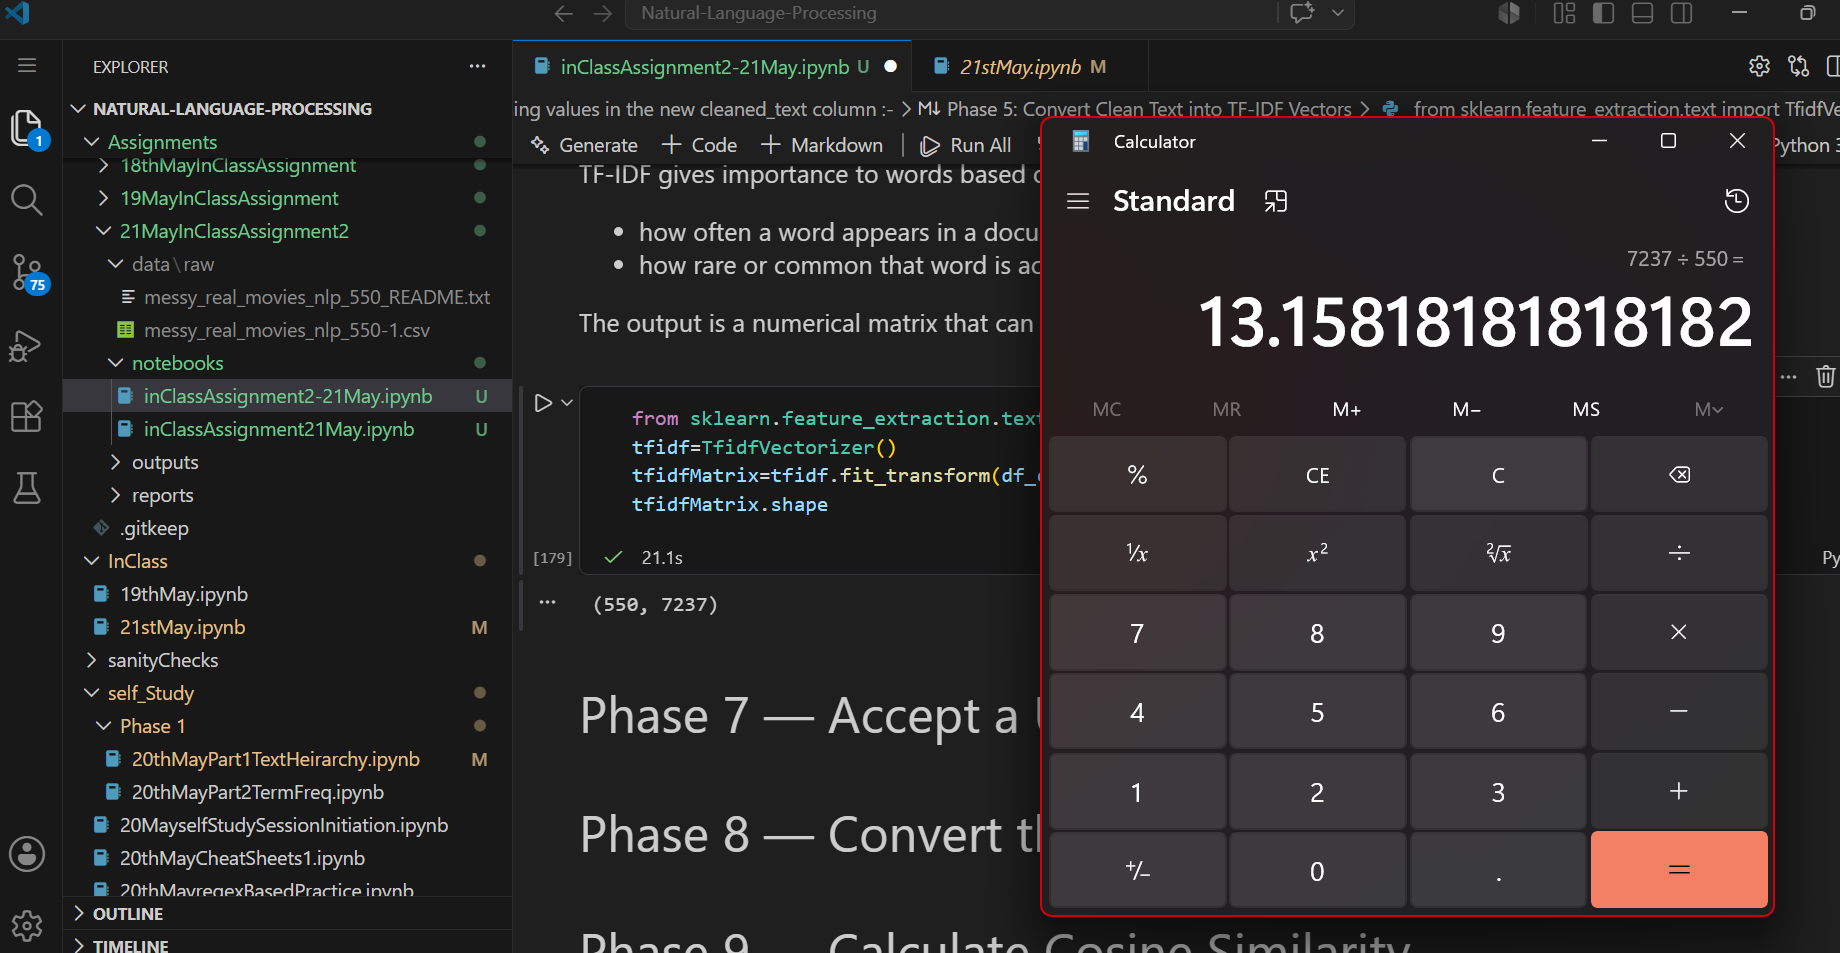


In [13]:
vocab=tfidf.get_feature_names_out()
print(f"Vocabulary Sample: {vocab[:10]}")

Vocabulary Sample: ['aaliyah' 'aames' 'aaron' 'aasif' 'abandon' 'abbey' 'abbie' 'abduct'
 'abducts' 'abdul']


## Phase 6: Accept and Preprocess the User Query

In this phase, the notebook accepts a user search query and cleans it using the same preprocessing function used for the movie text.

The raw query is stored in `movieName`.

The cleaned query is stored in `cleanMovieName`.

This is important because the movie documents and the user query must follow the same cleaning process before comparison.


In [14]:
movieName=input("Enter what you want to watch:\n")
cleanMovieName=preprocessText(movieName)
print(f"Original: \n{movieName}")
print(f"Cleaned: \n{cleanMovieName}")

Original: 
Resident Evil
Cleaned: 
resident evil


## Phase 7: Convert the Query into a TF-IDF Vector

Use only `transform()` for this phase.

`fit()` learns a vocabulary from text.

`transform()` uses an already learned vocabulary and converts new text into numbers.

The notebook already trained the TF-IDF vectorizer on `df_copy["cleaned_text"]`, so the query must use the same learned vocabulary.

If we used `fit()` or `fit_transform()` again on `cleanMovieName`, the vocabulary learned from the movie dataset would be reset or replaced. That would make the query vector incompatible with `tfidfMatrix`.


In this phase, the cleaned user query `cleanMovieName` is converted into a TF-IDF vector.

The query vector is stored in `cleanMovieNameVec`.

The notebook uses:

- `tfidf.transform([cleanMovieName])`

This keeps the query in the same TF-IDF feature space as the movie documents.


In [15]:
cleanMovieNameVec=tfidf.transform([cleanMovieName])
print(f"All movies shape:\n{tfidfMatrix.shape}")
print(f"Movie Query Shape:-\n{cleanMovieNameVec.shape}")

All movies shape:
(550, 7434)
Movie Query Shape:-
(1, 7434)


## Phase 8: Calculate Cosine Similarity

In this phase, the notebook compares the cleaned user query vector with all movie TF-IDF vectors.

The cosine similarity scores are stored in `score`.

A higher cosine similarity score means the movie is more relevant to the user query.


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
np.set_printoptions(precision=10)
score=cosine_similarity(cleanMovieNameVec, tfidfMatrix)
score[0][:5] #The first 5 movies in your dataset are not similar to your query, or they share no useful TF-IDF words with your query.

array([0., 0., 0., 0., 0.])

In [17]:
print(score.max())

0.18060709454066154


## Phase 9: Return the Top 3 Results


## Index Slicing and Sorting Guide

| Code Component | What It Does | Why It Is Used |
| :--- | :--- | :--- |
| `score[0]` | Extracts all similarity scores for the query. | `cosine_similarity()` returns a 2D array, so `score[0]` selects the first query's scores. |
| `.argsort()` | Sorts the scores but returns their index positions, not the score values. | This tells us which movie rows have the lowest-to-highest scores. |
| `[::-1]` | Reverses the sorted index order. | This changes the order from lowest-to-highest into highest-to-lowest. |
| `[:3]` | Selects only the first three indexes. | This keeps only the top 3 most similar movies. |

The final indexes are stored in `top3Indexes`.


In [18]:
top3Indexes = score[0].argsort()[::-1][:3]
print(top3Indexes)

[499 197 336]


## Pandas Row Extraction with `.iloc`

| Code Component | Direct Meaning | Behind-the-Scenes Action |
| :--- | :--- | :--- |
| `df_copy` | The working movie DataFrame | Contains the movie data and generated columns such as `combined_text` and `cleaned_text`. |
| `.iloc[...]` | Select rows by integer position | Extracts rows using the row positions stored in `top3Indexes`. |
| `top3Indexes` | Indexes of the top 3 matching movies | Generated from the sorted cosine similarity scores. |
| `.copy()` | Creates a separate result table | Prevents accidental changes to the original `df_copy` DataFrame. |

The selected top 3 rows are stored in `top3Movies`.


In [19]:
top3Movies = df_copy.iloc[top3Indexes].copy()

## Add Similarity Scores to the Result DataFrame

| Code Component | Meaning / Role | Behind-the-Scenes Action |
| :--- | :--- | :--- |
| `top3Movies["similarity_score"]` | Creates a new result column | Stores the cosine similarity score for each selected movie. |
| `score[0][top3Indexes]` | Gets scores for the selected top 3 movies | Pulls only the scores that match the row positions stored in `top3Indexes`. |
| `pd.set_option("display.max_colwidth", None)` | Expands displayed text columns | Allows long descriptions, actors, and other text fields to display without being truncated. |


In [20]:
top3Movies["similarity_score"] = score[0][top3Indexes]
pd.set_option("display.max_colwidth", None)

# Showing the Final Results


In [21]:
top3Movies[[
    "title",
    "description",
    "genre",
    "actors",
    "directors",
    "release_date",
    "vote_average",
    "similarity_score"
]]

,title,description,genre,actors,directors,release_date,vote_average,similarity_score
499,Resident Evil: Apocalypse,"As the city is locked down under quarantine, Alice joins a small band of elite soldiers, enlisted to rescue the missing daughter of the creator of the mutating T-virus. It's a heart-pounding race against time as the group faces off against hordes of blood- thirsty zombies, stealthy Lickers, mutant canines and the most sinister foe yet.","Horror, Action, Science Fiction","Milla Jovovich, Sienna Guillory, Oded Fehr, Thomas Kretschmann, Sophie Vavasseur",Alexander Witt,10-09-2004,6.1,0.180607
197,Fruitvale Station,"The true story of Oscar, a 22-year-old Bay Area resident, who crosses paths with friends, enemies, family, and strangers on the last day of 2008.",Drama,Michael B. Jordan ; Octavia Spencer ; Melonie Diaz ; Ahna O'Reilly ; Kevin Durand,Ryan Coogler,25-07-2013,7.3,0.155732
336,Mirror Mirror,"After she spends all her money, an evil enchantress queen schemes to marry a handsome, wealthy prince. There's just one problem - he's in love with a beautiful princess, Snow White. Now, joined by seven rebellious dwarves, Snow White launches an epic battle of good vs. evil...","Adventure, Fantasy, Drama, Comedy, Science Fiction, Family","Julia Roberts, Lily Collins, Armie Hammer, Nathan Lane, Martin Klebba",Tarsem Singh,15-03-2012,5.5,0.139862


## Phase 10: Test with Multiple Queries

This section is reserved for testing the search engine with different user queries and checking whether the returned movies are relevant.


## Phase 11: Final Explanation / Report Section

This section is reserved for the final written explanation of the project, including the purpose, workflow, preprocessing steps, TF-IDF vectorization, cosine similarity calculation, and final output interpretation.
